In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
# Create dataset (as per PDF structure)

np.random.seed(42)
n = 150  # large dataset to avoid errors

df = pd.DataFrame({
    'Study_Hours': np.random.randint(1, 10, n),
    'Attendance': np.random.randint(50, 100, n),
    'Previous_Marks': np.random.randint(40, 100, n),
    'Assignments': np.random.randint(5, 10, n),
    'Internal_Marks': np.random.randint(15, 40, n)
})

# Target variable (Pass/Fail logic)
df['Final_Result'] = np.where(
    (df['Study_Hours'] > 4) &
    (df['Attendance'] > 70) &
    (df['Previous_Marks'] > 60),
    'Pass',
    'Fail'
)

# Save dataset
df.to_csv("student_data.csv", index=False)

df.head()

,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks,Final_Result
0,7,61,67,9,24,Fail
1,4,88,69,9,26,Fail
2,8,51,68,5,31,Fail
3,5,52,85,9,20,Fail
4,7,98,92,9,21,Pass


In [7]:
df = pd.read_csv("student_data.csv")
df.head()

,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks,Final_Result
0,7,61,67,9,24,Fail
1,4,88,69,9,26,Fail
2,8,51,68,5,31,Fail
3,5,52,85,9,20,Fail
4,7,98,92,9,21,Pass


In [9]:
# Check missing values
print(df.isnull().sum())

# Convert categorical (Pass/Fail → 1/0)
le = LabelEncoder()
df['Final_Result'] = le.fit_transform(df['Final_Result'])

df.head()

Study_Hours       0
Attendance        0
Previous_Marks    0
Assignments       0
Internal_Marks    0
Final_Result      0
dtype: int64


,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks,Final_Result
0,7,61,67,9,24,0
1,4,88,69,9,26,0
2,8,51,68,5,31,0
3,5,52,85,9,20,0
4,7,98,92,9,21,1


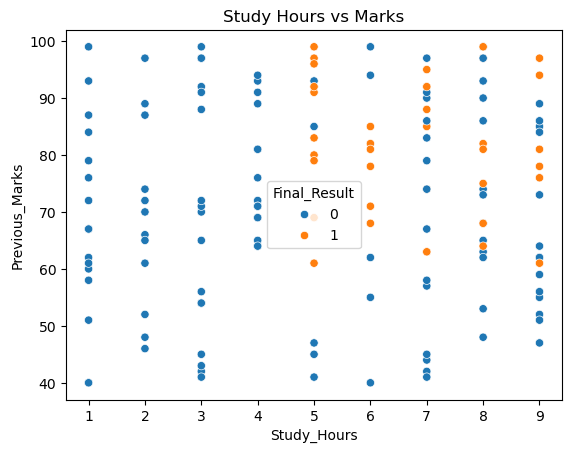

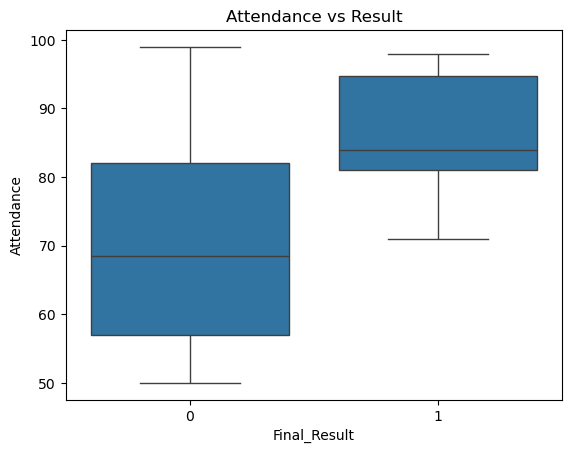

In [11]:
# Study Hours vs Marks
plt.figure()
sns.scatterplot(x='Study_Hours', y='Previous_Marks', hue='Final_Result', data=df)
plt.title("Study Hours vs Marks")
plt.show()

# Attendance vs Result
plt.figure()
sns.boxplot(x='Final_Result', y='Attendance', data=df)
plt.title("Attendance vs Result")
plt.show()

In [13]:
# Select important features (as per PDF)
X = df[['Study_Hours', 'Attendance', 'Previous_Marks']]
y = df['Final_Result']

In [15]:
# Normalize data
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [17]:
# Stratified split to avoid imbalance issues
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)